# Übungsblatt Seaborn Catplot


## Aufgaben


Die folgenden Aufgaben kannst du alle mit Catplot von Seaborn lösen. Einige Datasets kannst du direkt von Seaborn laden. 

Das Dataset 'winequality.csv' findest du auf GitHub.

Bei Aufgabe 6 wird zusätzlich etwas Recherchearbeit benötigt um die Aufgabe zu lösen.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl

mpl.pyplot.ion()

### 1.
Lade als erstes das "Titanic"-Dataset von Seaborn. Erstelle ein gruppiertes Balkendiagramm, das die Anzahl der Überlebenden in jeder Klasse (1., 2. und 3. Klasse) anzeigt. Die Balken sollen nach Überlebensstatus (Überlebt und Gestorben) farblich kodiert sein. Ändere zusätzlich die Farbpalette, um den Plot etwas schöner zu gestalten.

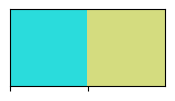

In [2]:
palette = sns.color_palette("rainbow", 2)
sns.palplot(palette)

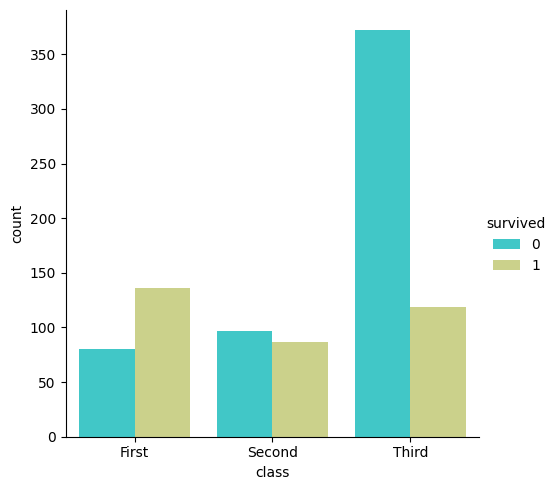

In [3]:
titanic = sns.load_dataset("titanic")
sns.catplot(x="class", hue="survived", data=titanic, kind="count", palette="rainbow")

### 2.
Erstelle einen Boxplot, der die Verteilung der sepal_length für jede Art im Datensatz IRIS darstellt.

![Iris_Dataset][def]

[def]: Iris_Dataset.png

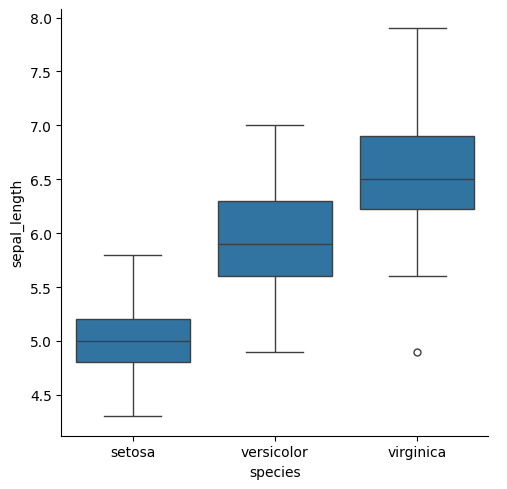

In [4]:
iris = sns.load_dataset("iris")
sns.catplot(data=iris, kind="box", x="species", y="sepal_length")

### 3.
Lade das Penguins-Dataset von Seaborn und erstelle einen "Swarmplot" mit der Verteilung der Schnabellänge von Pinguinen basierend auf der Pinguinart.

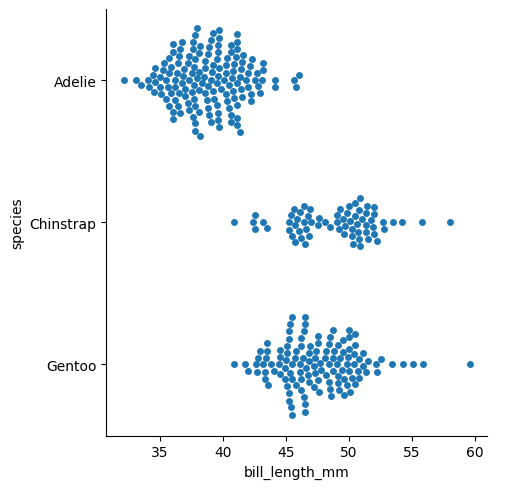

In [5]:
penguins = sns.load_dataset("penguins")
sns.catplot(x="bill_length_mm", kind="swarm", y="species", data=penguins)

### 4.
Verwende das Penguins-Dataset um die Verteilung des Körpergewichts von Pinguinen auf verschiedenen Inseln für verschiedene Arten und Geschlechter in Violinplots darzustellen. Ändere die Reihenfolge der Inseln nach Alphabet und füge noch eine andere Farbpalette hinzu.

Die Interpretation von Violinplots ist nicht ganz einfach. Unter diesem Link findest du eine Erklärung: https://towardsdatascience.com/violin-plots-explained-fb1d115e023d

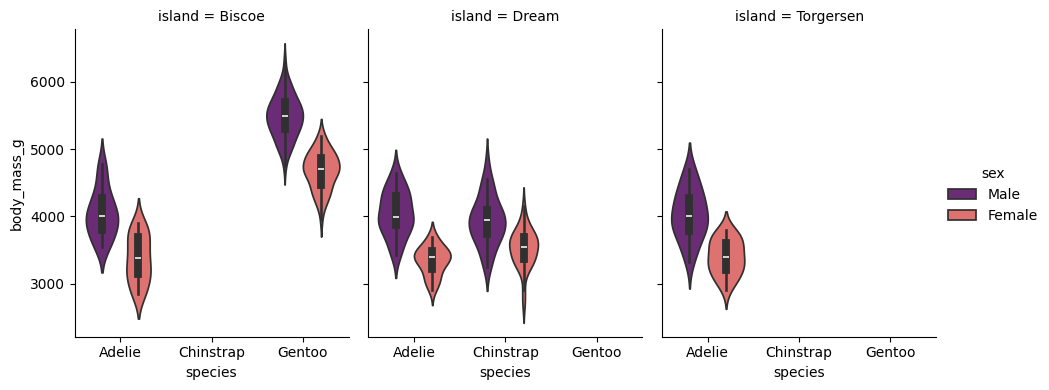

In [6]:
islands = list(penguins["island"].unique())
islands.sort()
sns.catplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    col="island",
    col_order=islands,
    kind="violin",
    palette="magma",
    height=4,
    aspect=0.8,
)

### 5.
Benutze für diese Aufgabe das Titanic-Dataset.

Erstelle ein Balkendiagramm, das die Anzahl der Überlebenden in jeder Klasse, Geschlecht und Abfahrtshafen (C, Q und S) anzeigt. Probiere verschiedene Anordnungen der Variablen aus und ändere die Farbpalette, um den Plot etwas schöner zu gestalten.

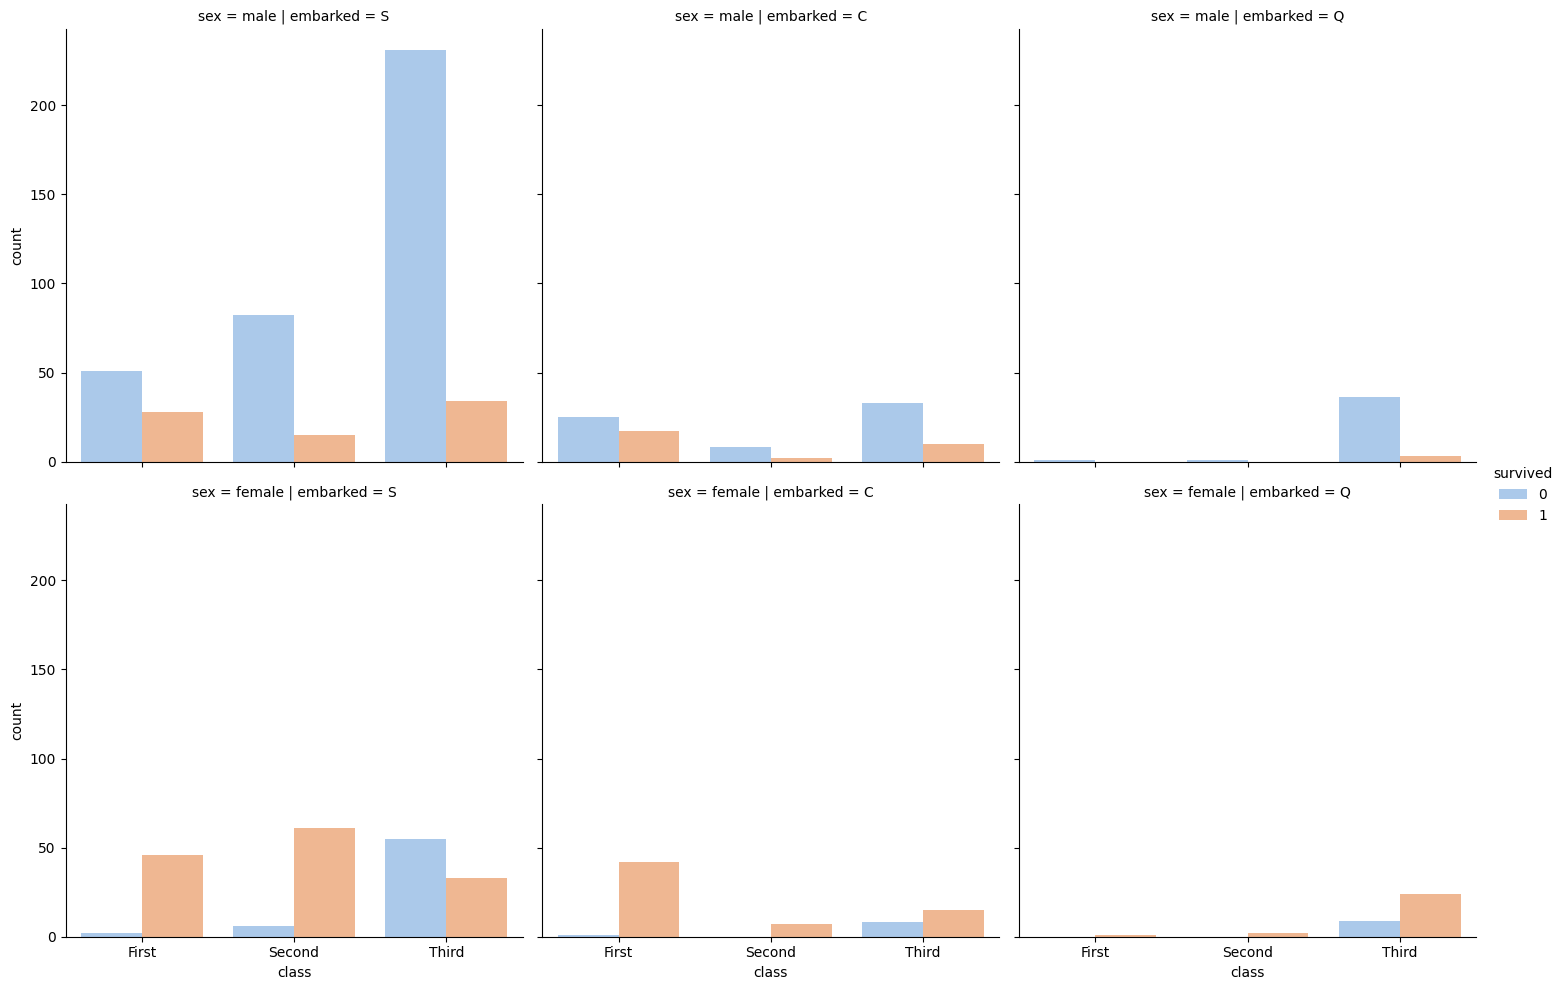

In [7]:
sns.catplot(
    x="class",
    hue="survived",
    col="embarked",
    row="sex",
    data=titanic,
    kind="count",
    palette="pastel",
)

### 6. 
1. Lade die Datei 'winequality.csv' von GitHub herunter und lese sie als DataFrame ein. 
2. Entferne alle fehlenden Werte aus dem Datensatz mit Hilfe der Funktion dropna(). Falls du nicht mit dieser Funktion vertraut bist, kannst du sie einfach googeln, um mehr darüber zu erfahren.
3. Google die Funktion cut() von Pandas und finde heraus, wie man Daten in Intervalle aufteilt und Labels zu den Intervallen erstellt. 
4. Erstelle nun einen Violinplot, der den Zusammenhang zwischen pH und Qualität der Weine visualisiert. Ausserdem sollen Alkoholgehalt und Weintyp mit einbezogen werden. Ändere zusätzlich noch die Farben des Plots.
5. Füge einen Titel "Weinqualit in Abhängigkeit von pH-Wert und Alkoholgehalt" hinzu
6. Ändere die Beschriftung der x und y Achse in "pH" und "Qualität"
7. Ändere die Beschriftung der Zeilen in "Alkoholgehalt" anstatt "alcohol_group"
8. Ändere die Beschriftung der Legende in "Weintyp"
9. Erstelle eine neue Liste mit den Labels für die pH Gruppen in umgekehrter Reihenfolge und ändere die Beschriftung der x-Achse.
10. Ändere die Beschriftung der Legende in "Weisswein" und "Rotwein"


In [8]:
# 1. Datensatz einlesen
df_wine = pd.read_csv("winequality.csv")

# 2. Datensatz bereinigen
df_wine_cleaned = df_wine.copy()
df_wine_cleaned.dropna(inplace=True)

df_wine_cleaned

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [9]:
# 3. Intervalle für pH und Alkohol
bins_pH = [2.5, 3.0, 3.5, 4, 4.5]
bins_alcohol = [8, 10, 12, 14, 16]

# Labels für die Intervalle
labels_pH = ["sehr sauer", "sauer", "leicht sauer", "leicht basisch"]
labels_alc = ["sehr niedrig", "niedrig", "mittel", "hoch"]

# Füge eine neue Spalte "pH_group" und 'alcohol_group hinzu. Diese basieren auf der Spalte "pH" und 'alcohol'.
df_wine_cleaned["pH_group"] = pd.cut(
    df_wine_cleaned["pH"], bins=bins_pH, labels=labels_pH
)
df_wine_cleaned["alcohol_group"] = pd.cut(
    df_wine_cleaned["alcohol"], bins=bins_alcohol, labels=labels_alc
)
df_wine_cleaned

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,pH_group,alcohol_group
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,sehr sauer,sehr niedrig
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,sauer,sehr niedrig
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,sauer,niedrig
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,sauer,sehr niedrig
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,sauer,sehr niedrig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,sauer,sehr niedrig
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,sauer,niedrig
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,sauer,niedrig
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,leicht sauer,niedrig


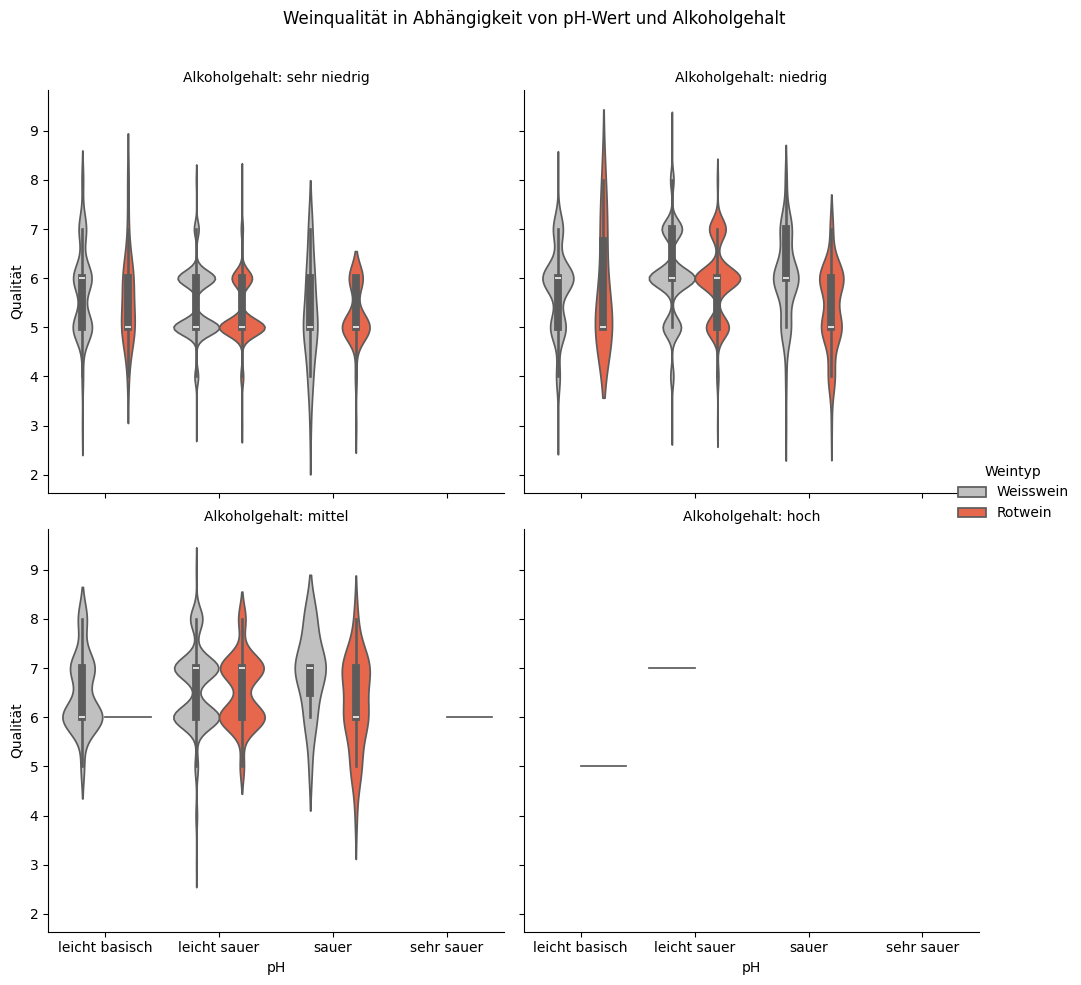

In [10]:
# Farben für die Weintypen
custom_palette = sns.color_palette(["#C0C0C0", "#FF5733"])

# 4. Erstelle den Violinplot
cat = sns.catplot(
    x="pH_group",
    y="quality",
    hue="type",
    col="alcohol_group",
    col_wrap=2,
    kind="violin",
    palette=custom_palette,
    data=df_wine_cleaned,
)

# 5. Füge einen Titel "Weinqualit in Abhängigkeit von pH-Wert und Alkoholgehalt" hinzu
cat.figure.subplots_adjust(top=0.90)
cat.figure.suptitle("Weinqualität in Abhängigkeit von pH-Wert und Alkoholgehalt")
# 6. Ändere die Beschriftung der x und y Achse in "pH" und "Qualität"
cat.set_axis_labels("pH", "Qualität")
# 7. Ändere die Beschriftung der Zeilen in "Alkoholgehalt" anstatt "alcohol_group"
cat.set_titles(col_template="Alkoholgehalt: {col_name}")
# 8. Ändere die Beschriftung der Legende in "Weintyp"
cat._legend.set_title("Weintyp")
# 9. Erstelle eine neue Liste mit den Labels für die pH Gruppen in umgekehrter Reihenfolge und ändere die Beschriftung der x-Achse.
labels_pH_reverse = list(reversed(labels_pH))
cat.set_xticklabels(labels_pH_reverse)
# 10. Ändere die Beschriftung der Legende in "Weisswein" und "Rotwein"
new_labels = ["Weisswein", "Rotwein"]
for t, l in zip(cat._legend.texts, new_labels):
    t.set_text(l)

# Übungsblatt Seaborn Heatmap und Relplot


## Aufgaben


Die folgenden Aufgaben kannst du mit Heatmap und Relplot von Seaborn lösen.

In [11]:
# Lade die nötige Bibliotheken
import pandas as pd
import seaborn as sns

### 1.
Lade als erstes das folgende Dataset:'FoodAccessResearchAtlasData2019.xlsx'

Das Laden des Files kann aufgrund der Grösse einige Zeit in Anspruch nehmen. 

Erstelle mit Relplot einen Scatterplot, der die Armutsrate im Staat Alabama auf der y-Achse und das Median Familien-Einkommen auf der x-Achse abbildet. Teile die Daten zusätzlich farblich nach Urbanen und nicht-Urbanen Zonen auf. Ändere zusätzlich die Farbpalette.


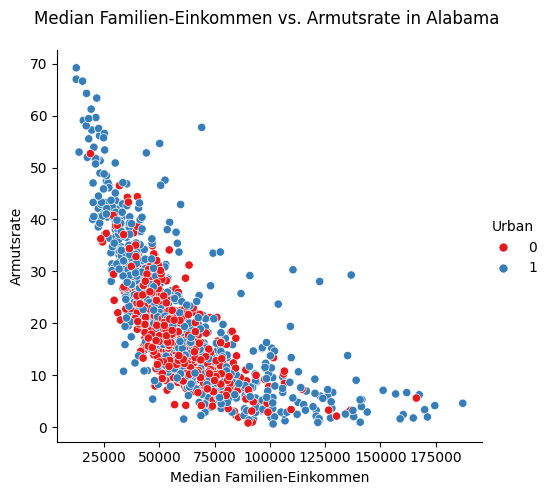

In [12]:
data_poverty = pd.read_excel(
    "FoodAccessResearchAtlasData2019.xlsx", sheet_name="Food Access Research Atlas"
)

# Daten nach Bundesstaat Alabama filtern
data_alabama = data_poverty[data_poverty["State"] == "Alabama"]

# Plot erstellen mit relplot
rel = sns.relplot(
    data=data_alabama,
    x="MedianFamilyIncome",
    y="PovertyRate",
    hue="Urban",
    palette="Set1",
    kind="scatter",
)
# Plot beschriften
rel.figure.subplots_adjust(top=0.90)

rel.figure.suptitle("Median Familien-Einkommen vs. Armutsrate in Alabama")
rel.set(xlabel="Median Familien-Einkommen", ylabel="Armutsrate")

### 2.
Erstelle eine Heatmap, die die Korrelation zwischen den folgenden Variablen anzeigt: 'Pop2010', 'OHU2010', 'PovertyRate', 'MedianFamilyIncome','lapophalf','lahunvhalf','lablack1','LILATracts_1And10'

Tip: Im Excel File kann man die Bedeutung der Variablen nachlesen. 

Text(0.5, 1.0, 'Heatmap der Korrelationen')

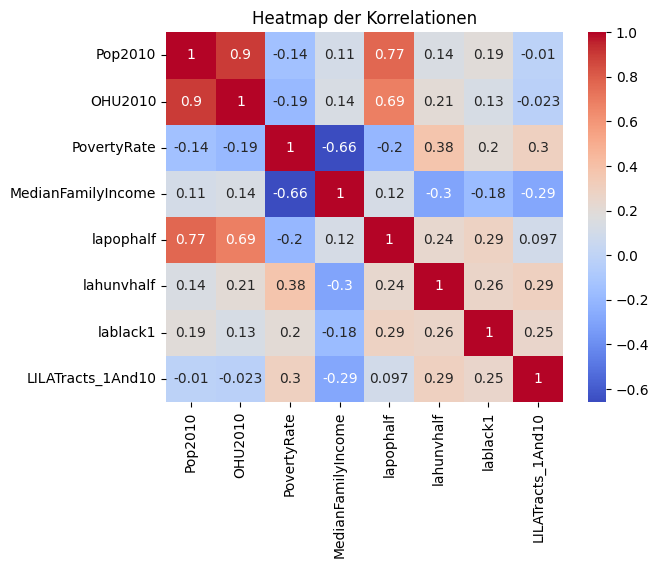

In [13]:
# POP2010	Population, tract total	Population count from 2010 census
# OHU2010	Housing units, total	Occupied housing unit count from 2010 census
# PovertyRate	Tract poverty rate	Share of the tract population living with income at or below the Federal poverty thresholds for family size
# MedianFamilyIncome	Tract median family income	Tract median family income
# Daten für HEATMAP vorbereiten
heatmap_data = data_poverty[
    [
        "Pop2010",
        "OHU2010",
        "PovertyRate",
        "MedianFamilyIncome",
        "lapophalf",
        "lahunvhalf",
        "lablack1",
        "LILATracts_1And10",
    ]
]

# Korrelationsmatrix berechnen
correlation_matrix = heatmap_data.corr()

# Heatmap erstellen
heat = sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

# Titel anzeigen
heat.set_title("Heatmap der Korrelationen")

### 3.
Lese die Datei 'CyberCrime_data ein. Erstelle einen Relplot mit der totalen Anzahl von Straftaten pro Jahr. Teile die Straftaten farblich nach den Überkategorien auf. 

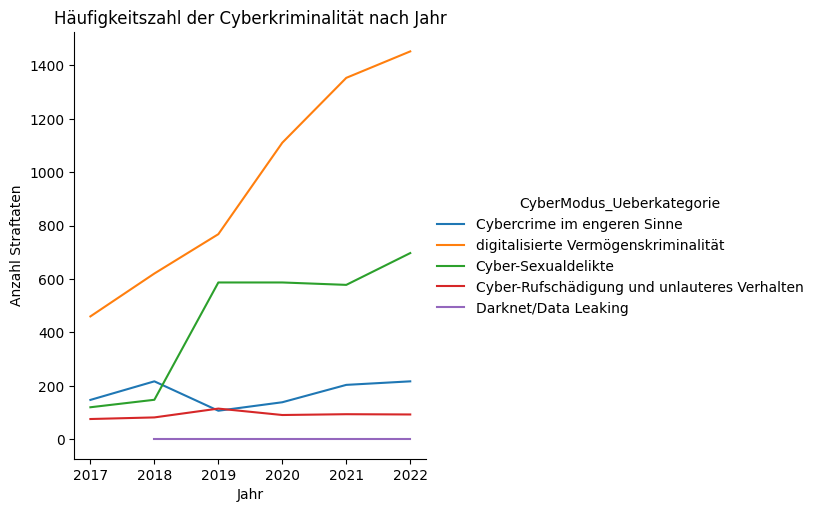

In [14]:
# Daten aus Excel einlesen
data = pd.read_csv("CyberCrime_data.csv", sep=";")

# Relplot erstellen
rel = sns.relplot(
    data=data,
    x="Ausgangsjahr",
    y="Straftaten_total",
    hue="CyberModus_Ueberkategorie",
    kind="line",
    errorbar=None,
)


# Plot beschriften
rel.set(
    xlabel="Jahr",
    ylabel="Anzahl Straftaten",
    title="Häufigkeitszahl der Cyberkriminalität nach Jahr",
)

### 4.
Erstelle aus den Cybercrime-Daten eine Heatmap mit der Anzahl Straftaten pro Jahr, unterteil in die Überkategorien. Dazu kannst du zuerst eine Pivot-Tabelle erstellen (siehe: https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html)

[Text(0.5, 23.52222222222222, 'Ausgangsjahr'),
 Text(50.72222222222219, 0.5, 'CyberModus_Ueberkategorie'),
 Text(0.5, 1.0, 'Heatmap der Straftaten')]

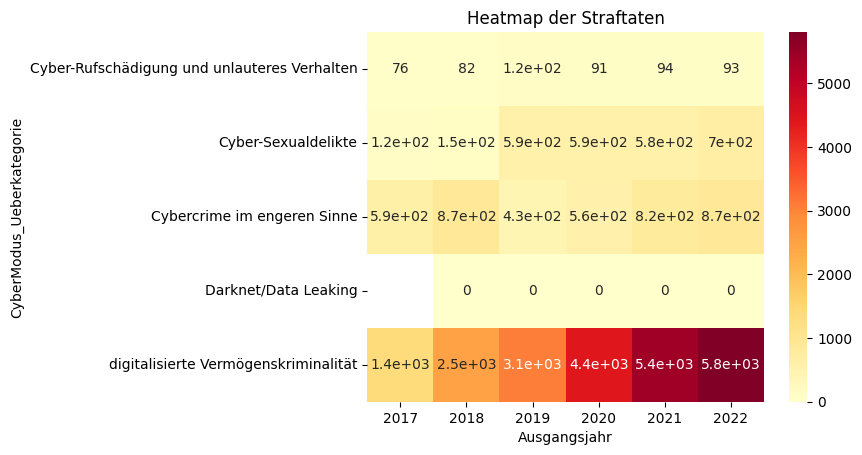

In [15]:
# Pivot-Tabelle erstellen, um die Daten für die Heatmap zu transformieren
pivot_table = data.pivot_table(
    index="CyberModus_Ueberkategorie",
    columns="Ausgangsjahr",
    values="Straftaten_total",
    aggfunc="sum",
)

# Heatmap erstellen
heat = sns.heatmap(pivot_table, annot=True, cmap="YlOrRd")

# Achsentitel und Plot-Titel hinzufügen
heat.set(
    xlabel="Ausgangsjahr",
    ylabel="CyberModus_Ueberkategorie",
    title="Heatmap der Straftaten",
)

### 5.
Wir haben wieder einmal Daten zu Wein. Lese den Datensatz 'wine_data.xlsx' ein und erstelle wieder zuerst eine Heatmap, um die Daten zu analysieren.

Die Beschreibung der Variablen:
* "Class": Die Klassenzuordnung des Weins (Güteklassen).
* "Alcohol": Der Alkoholgehalt des Weins.
* "Malic Acid": Der Gehalt an Äpfelsäure im Wein.
* "Ash": Der Gehalt an anorganischen Bestandteilen im Wein (insbesondere Mineralien).
* "Alcalinity of Ash": Die Alkalinität der Asche im Wein, d.h. der pH-Wert der Asche.
* "Magnesium": Der Magnesiumgehalt im Wein.
* "Total Phenols": Die Gesamtmenge an Phenolverbindungen im Wein.
* "Flavanoids": Der Gehalt an Flavonoiden im Wein, eine Gruppe von Phenolverbindungen.
* "Nonflavanoid phenols": Der Gehalt an nicht-flavonoiden Phenolverbindungen im Wein.
* "Proanthocyanins": Der Gehalt an Proanthocyanidinen im Wein, eine Klasse von Phenolverbindungen.
* "Color intensity": Die Intensität der Farbe des Weins.
* "Hue": Der Farbton des Weins.
* "OD280/OD315 of diluted wines": Das Verhältnis der optischen Dichte bei 280 nm zur optischen Dichte bei 315 nm, gemessen an verdünnten Weinen.
* "Proline": Die Konzentration von Proline, einer Aminosäure, im Wein.


Text(0.5, 1.0, 'Heatmap der Weinattribute')

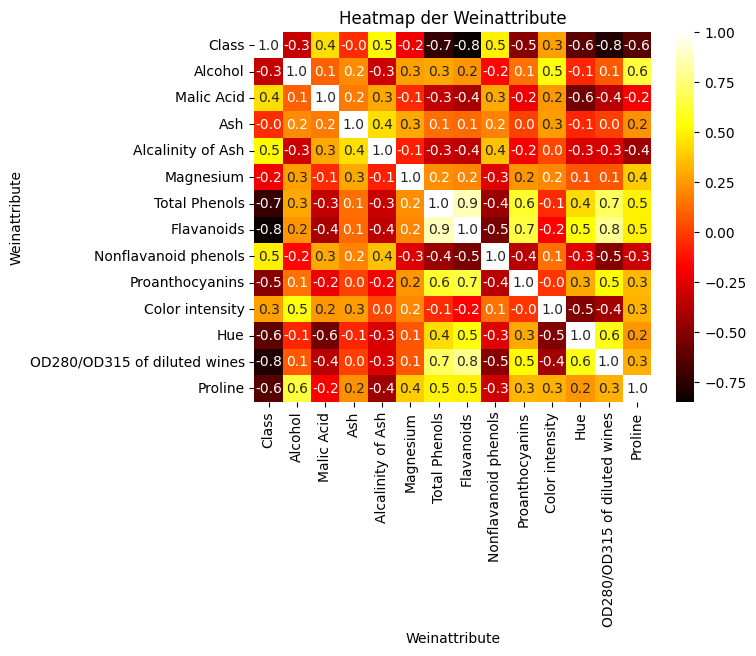

In [16]:
data_wine = pd.read_excel("wine_data.xlsx")

# Attribute extrahieren
attributes = [
    "Class",
    "Alcohol",
    "Malic Acid",
    "Ash",
    "Alcalinity of Ash",
    "Magnesium",
    "Total Phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline",
]

# Heatmap-Daten erstellen
heatmap_data = data_wine[attributes].corr()

# Heatmap plotten

heat = sns.heatmap(heatmap_data, cmap="hot", annot=True, fmt=".1f", cbar=True)

# Titel und Achsenbeschriftungen setzen
heat.set_xlabel("Weinattribute")
heat.set_ylabel("Weinattribute")
heat.set_title("Heatmap der Weinattribute")

### 6.
Erstelle mit Relplot einen Scatterplot, der die Farbintensität in Abhängigkeit der Proanthocyane abbildet. Farblich sollen sich die Klassen unterscheiden und die Grösse der Datenpunkte soll sich anhand der Grösse der Proline ändern. 

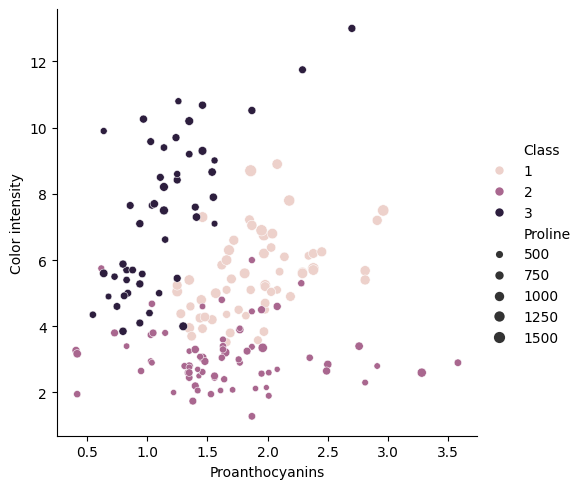

In [17]:
data_wine = pd.read_excel("wine_data.xlsx")

# Scatterplot erstellen
sns.relplot(
    x="Proanthocyanins",
    y="Color intensity",
    size="Proline",
    hue="Class",
    data=data_wine,
)